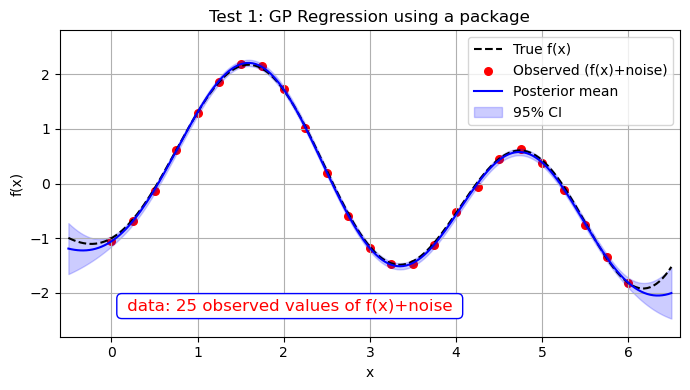

In [2]:
# Test 1: GP regression using scikit-learn’s built-in GaussianProcessRegressor
# data: 25 observed values of f(x)+noise
%reset -f

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
rng = np.random.default_rng(seed=10) #rng = np.random.default_rng()

# Training data
f = lambda x: np.sin(x)-np.exp(0.1*x)*np.cos(2*x) 
n1=4; nX=6*n1+1
X = np.linspace(0, 6, nX).reshape(-1, 1)
noise_std = 0.05
y = f(X).ravel() + noise_std * rng.normal(size=len(X))

# Kernel = signal kernel
kernel = RBF(length_scale=1.0)

# Fit GP (add noise kernel and ridge kernel)
gp = GaussianProcessRegressor(kernel=kernel, alpha=noise_std**2+1e-8, optimizer=None)
gp.fit(X, y)

# One-line prediction
X_star = np.linspace(-0.5, 6.5, 201).reshape(-1, 1)
y_mean, y_std = gp.predict(X_star, return_std=True)

# Plot
plt.figure(figsize=(7,4))
plt.plot(X_star, f(X_star), 'k--', label="True f(x)")
plt.scatter(X, y, c='r', s=30, label="Observed (f(x)+noise)")
plt.plot(X_star, y_mean, 'b', label="Posterior mean")
plt.fill_between(X_star.ravel(),
                 y_mean - 2*y_std,
                 y_mean + 2*y_std,
                 color='b', alpha=0.2, label="95% CI")
plt.legend(); plt.xlim(-0.6,6.6); plt.ylim(-2.8,2.8)
plt.title("Test 1: GP Regression using a package")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.grid(True)
plt.text(0.1, 0.1, ' data: 25 observed values of f(x)+noise ', \
        transform=plt.gca().transAxes, fontsize=12, color='red',ha='left', va='center',
        bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.3'))
plt.tight_layout()
plt.show()


In [4]:
y_std[0]

np.float64(0.23303152040431968)

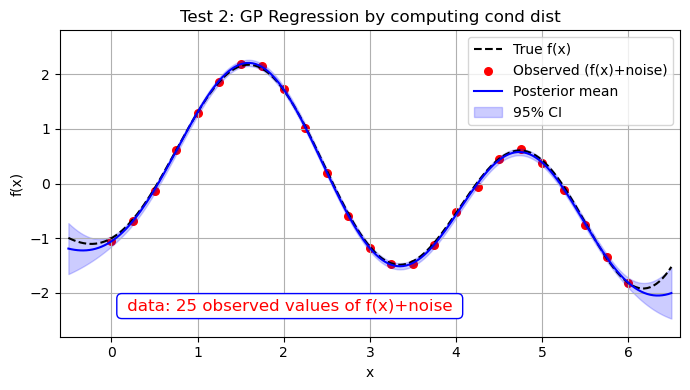

In [2]:
# Test 2: GP regression by computing conditional distribution
# data: 25 observed values of f(x)+noise
%reset -f

import numpy as np
from sklearn.gaussian_process.kernels import RBF
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=10) #rng = np.random.default_rng()

# --------------------------
# 1. Training data
# --------------------------
f = lambda x: np.sin(x)-np.exp(0.1*x)*np.cos(2*x) 
n1=4; nX=6*n1+1
X = np.linspace(0, 6, nX).reshape(-1, 1)
noise_std = 0.05
y = f(X).ravel() + noise_std * rng.normal(size=len(X))

# --------------------------
# 2. Kernel = signal kernel
# --------------------------
kernel = RBF(length_scale=1.0)
K = kernel(X)

# --------------------------
# 3. Predictive posterior on a test grid (add noise kernel and ridge kernel)
# --------------------------
X_star = np.linspace(-0.5, 6.5, 201).reshape(-1, 1)
K_Ds = kernel(X, X_star) # covariance of (Data, y_star)
K_ss = kernel(X_star)
#
K_inv = np.linalg.inv(K + (noise_std**2+1e-8)*np.eye(K.shape[0]))
mu_star = K_Ds.T @ K_inv @ y
cov_star = K_ss - K_Ds.T @ K_inv @ K_Ds
std_star = np.sqrt(np.diag(cov_star))

# --------------------------
# 4. Plot
# --------------------------
plt.figure(figsize=(7,4))
plt.plot(X_star, f(X_star), 'k--', label="True f(x)")
plt.scatter(X, y, c='r', s=30, label="Observed (f(x)+noise)")
plt.plot(X_star, mu_star, 'b', label="Posterior mean")
plt.fill_between(X_star.ravel(),
                 mu_star - 2*std_star,
                 mu_star + 2*std_star,
                 color='b', alpha=0.2, label="95% CI")
plt.legend(); plt.xlim(-0.6,6.6); plt.ylim(-2.8,2.8)
plt.title("Test 2: GP Regression by computing cond dist")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.grid(True)
plt.text(0.1, 0.1, ' data: 25 observed values of f(x)+noise ', \
        transform=plt.gca().transAxes, fontsize=12, color='red',ha='left', va='center',
        bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.3'))
plt.tight_layout()
plt.show()


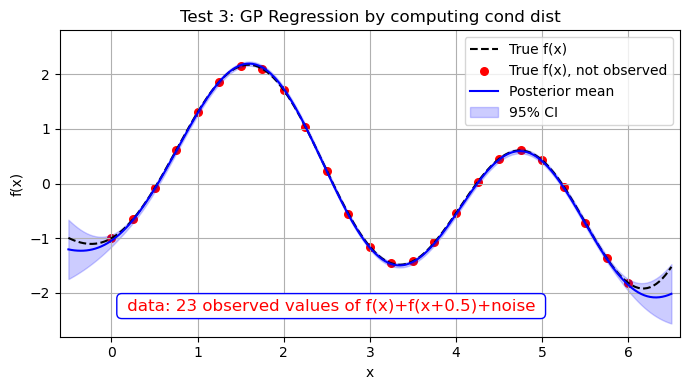

In [3]:
# Test 3: GP regression by computing conditional distribution
# data: 23 observed values of f(x)+f(x+0.5)+noise
%reset -f

import numpy as np
from sklearn.gaussian_process.kernels import RBF
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=10) #rng = np.random.default_rng()

# --------------------------
# 1. Training data
# --------------------------
f = lambda x: np.sin(x)-np.exp(0.1*x)*np.cos(2*x)
n1=4; nX=6*n1+1
X = np.linspace(0, 6, nX).reshape(-1, 1)
noise_std = 0.05
y_true = f(X).ravel();
dn=n1//2 # f(x)+f(x+0.5) is observed
W = np.eye(nX-dn, nX, k=0) + np.eye(nX-dn, nX, k=dn)
y_obs = W@y_true + noise_std * rng.normal(size=W.shape[0])

# --------------------------
# 2. Kernel = signal kernel
# --------------------------
kernel = RBF(length_scale=1.0)
K = W@kernel(X)@W.T

# --------------------------
# 3. Predictive posterior on a test grid (add noise kernel and ridge kernel)
# --------------------------
X_star = np.linspace(-0.5, 6.5, 201).reshape(-1, 1)
K_Ds = W@kernel(X, X_star) # covariance of (Data, y_star)
K_ss = kernel(X_star)
#
K_inv = np.linalg.inv(K + (noise_std**2+1e-8)*np.eye(K.shape[0]))
mu_star = K_Ds.T @ K_inv @ y_obs
cov_star = K_ss - K_Ds.T @ K_inv @ K_Ds
std_star = np.sqrt(np.diag(cov_star))

# --------------------------
# 4. Plot
# --------------------------
plt.figure(figsize=(7,4))
plt.plot(X_star, f(X_star), 'k--', label="True f(x)")
plt.scatter(X, y_true, c='r', s=30, label="True f(x), not observed")
plt.plot(X_star, mu_star, 'b', label="Posterior mean")
plt.fill_between(X_star.ravel(),
                 mu_star - 2*std_star,
                 mu_star + 2*std_star,
                 color='b', alpha=0.2, label="95% CI")
plt.legend(); plt.xlim(-0.6,6.6); plt.ylim(-2.8,2.8)
plt.title("Test 3: GP Regression by computing cond dist")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.grid(True)
plt.text(0.1, 0.1, ' data: 23 observed values of f(x)+f(x+0.5)+noise ', \
        transform=plt.gca().transAxes, fontsize=12, color='red',ha='left', va='center',
        bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.3'))
plt.tight_layout()
plt.show()


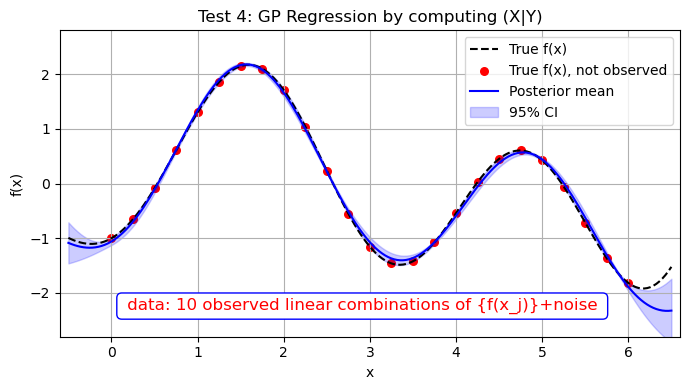

In [4]:
# Test 4: GP regression by computing conditional distribution
# data: 10 observed linear combinations of {f(x_j)}+noise
%reset -f

import numpy as np
from sklearn.gaussian_process.kernels import RBF
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=10) #rng = np.random.default_rng()

# --------------------------
# 1. Training data
# --------------------------
f = lambda x: np.sin(x)-np.exp(0.1*x)*np.cos(2*x)
n1=4; nX=6*n1+1
X = np.linspace(0, 6, nX).reshape(-1, 1)
noise_std = 0.05
y_true = f(X).ravel();
dn=n1//2 # f(x)+f(x+0.5) is observed
W = rng.standard_normal((10, nX))
y_obs = W@y_true + noise_std * rng.normal(size=W.shape[0])

# --------------------------
# 2. Kernel = signal kernel
# --------------------------
kernel = RBF(length_scale=1.0)
K = W@kernel(X)@W.T

# --------------------------
# 3. Predictive posterior on a test grid (add noise kernel and ridge kernel)
# --------------------------
X_star = np.linspace(-0.5, 6.5, 201).reshape(-1, 1)
K_Ds = W@kernel(X, X_star) # covariance of (Data, y_star)
K_ss = kernel(X_star)
#
K_inv = np.linalg.inv(K + (noise_std**2+1e-8)*np.eye(K.shape[0]))
mu_star = K_Ds.T @ K_inv @ y_obs
cov_star = K_ss - K_Ds.T @ K_inv @ K_Ds
std_star = np.sqrt(np.diag(cov_star))

# --------------------------
# 4. Plot
# --------------------------
plt.figure(figsize=(7,4))
plt.plot(X_star, f(X_star), 'k--', label="True f(x)")
plt.scatter(X, y_true, c='r', s=30, label="True f(x), not observed")
plt.plot(X_star, mu_star, 'b', label="Posterior mean")
plt.fill_between(X_star.ravel(),
                 mu_star - 2*std_star,
                 mu_star + 2*std_star,
                 color='b', alpha=0.2, label="95% CI")
plt.legend(); plt.xlim(-0.6,6.6); plt.ylim(-2.8,2.8)
plt.title("Test 4: GP Regression by computing (X|Y)")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.grid(True)
plt.text(0.1, 0.1, ' data: 10 observed linear combinations of {f(x_j)}+noise ', 
        transform=plt.gca().transAxes, fontsize=12, color='red',ha='left', va='center',
        bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.3'))
plt.tight_layout()
plt.show()
